Imports

In [250]:
import pandas as pd
from pathlib import Path
import importlib


#visualization to check elo rating
import matplotlib.pyplot as plt



#Loading the Elo Module
import sys
sys.path.append("/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject/notebooks/cleaning")

import elo as elo
importlib.reload(elo)

<module 'elo' from '/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject/notebooks/cleaning/elo.py'>

working directory

In [251]:
working_directory = Path.cwd().parent.parent
print(working_directory)

/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject


Bringing in placement file

In [252]:
pt_path = working_directory / "data" / "clean" / "placement_table.csv"
race_session_path = working_directory / "data" / "clean" / "race_session_meeting_info.csv" #to grab the race_num
placement_table = pd.read_csv(pt_path).drop(columns=["Unnamed: 0"])
race_session_info = pd.read_csv(race_session_path).drop(columns=["Unnamed: 0"])

In [253]:
placement_table[placement_table.position.isna()]

,date_start,driver,driver_number,position,points,gap_to_leader,meeting_key,session_key,dnf,dns,dsq,nc
17,2023-03-05 15:00:00+00:00,OCO,31,NaN,0.0,NaN,1141,7953,True,False,False,0
18,2023-03-05 15:00:00+00:00,LEC,16,NaN,0.0,NaN,1141,7953,True,False,False,0
19,2023-03-05 15:00:00+00:00,PIA,81,NaN,0.0,NaN,1141,7953,True,False,False,0
38,2023-03-19 17:00:00+00:00,ALB,23,NaN,0.0,NaN,1142,7779,True,False,False,0
39,2023-03-19 17:00:00+00:00,STR,18,NaN,0.0,NaN,1142,7779,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1414,2026-03-08 04:00:00+00:00,ALO,14,NaN,0.0,NaN,1279,11234,True,False,False,0
1415,2026-03-08 04:00:00+00:00,BOT,77,NaN,0.0,NaN,1279,11234,True,False,False,0
1416,2026-03-08 04:00:00+00:00,HAD,6,NaN,0.0,NaN,1279,11234,True,False,False,0
1417,2026-03-08 04:00:00+00:00,PIA,81,NaN,0.0,NaN,1279,11234,False,True,False,0


In [254]:
race_session_info = race_session_info[["start_date", "race"]]

In [255]:
placement_table = placement_table.merge(race_session_info, how="left", right_on=["start_date"], left_on = ["date_start"]).drop(columns=["date_start"])
placement_table["start_date"] = pd.to_datetime(placement_table["start_date"], utc=True)
placement_table["year"] = placement_table['start_date'].dt.year
placement_table = placement_table.rename(columns={"race":"race_num"})

In [256]:
placement_table.head()

,driver,driver_number,position,points,gap_to_leader,meeting_key,session_key,dnf,dns,dsq,nc,start_date,race_num,year
0,VER,1,1.0,25.0,0,1141,7953,False,False,False,0,2023-03-05 15:00:00+00:00,1,2023
1,PER,11,2.0,18.0,11.987,1141,7953,False,False,False,0,2023-03-05 15:00:00+00:00,1,2023
2,ALO,14,3.0,15.0,38.637,1141,7953,False,False,False,0,2023-03-05 15:00:00+00:00,1,2023
3,SAI,55,4.0,12.0,48.052,1141,7953,False,False,False,0,2023-03-05 15:00:00+00:00,1,2023
4,HAM,44,5.0,10.0,50.977,1141,7953,False,False,False,0,2023-03-05 15:00:00+00:00,1,2023


## Manual Overrides Table for when the API falls short
- the api doesnt tend to capture post race disqulifications well

In [257]:
overrides_df = pd.DataFrame({
    "year": [2023, 2023, 2026],
    "race_num": [19, 19, 1],
    "driver": ["HAM", "LEC", "STR"],
    "dsq_override": [True, True, None],
    "position_override": [None, None, None],
    "dns_override": [None, None, None],
    "dnf_override": [None, None, None],
    "nc_override": [None, None, True],
})

In [258]:
elo_table = elo.run_driver_elo_pipeline(
    placement_df=placement_table,
    overrides_df=overrides_df,
    year_col="year",
    race_col="race_num",
    driver_col="driver",
    position_col="position",
    dns_col="dns",
    dnf_col="dnf",
    dsq_col="dsq",
    nc_col="nc",
    init_elo=1500,
    k_factor=8,
    season_shrink=0.75,
    inactivity_shrink=0.75,
    return_matchups=False
)

/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject/notebooks/cleaning/elo.py:39: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  True only if a larger finish value is better.
/Users/jackguptill/Library/CloudStorage/OneDrive-Personal/Code/F1FantasyProject/notebooks/cleaning/elo.py:94: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  )


### Sanity Checks

In [259]:
(
    elo_table.groupby(["year", "race_num", "driver"])
    .size()
    .max()
)

1

In [260]:
elo_table["elo_before"].isna().sum()

np.int64(0)

In [261]:
min_year = elo_table["year"].min()

elo_table.loc[
    (elo_table["year"] == min_year) & (elo_table["race_num"] == 1),
    ["driver", "elo_before"]
].head()

,driver,elo_before
0,VER,1500.0
1,PER,1500.0
2,ALO,1500.0
3,SAI,1500.0
4,HAM,1500.0


In [262]:
driver_elo.groupby(["year","race_num"])["elo_delta"].sum().describe()

count    7.100000e+01
mean     1.501147e-16
std      2.128612e-14
min     -3.552714e-14
25%     -1.421085e-14
50%      0.000000e+00
75%      1.421085e-14
max      5.684342e-14
Name: elo_delta, dtype: float64

## Visualization of drivers elo over the years

In [263]:
# clean copy
elo_plot = elo_table.copy()

# sort in race order
elo_plot = elo_plot.sort_values(["year", "race_num", "driver"]).copy()

elo_plot["race_label"] = elo_plot["year"].astype(str) + "-" + elo_plot["race_num"].astype(str)

# continuous race index across all seasons
race_order = (
    elo_plot[["year", "race_num"]]
    .drop_duplicates()
    .sort_values(["year", "race_num"])
    .reset_index(drop=True)
)

race_order["race_index"] = range(1, len(race_order) + 1)

elo_plot = elo_plot.merge(race_order, on=["year", "race_num"], how="left")

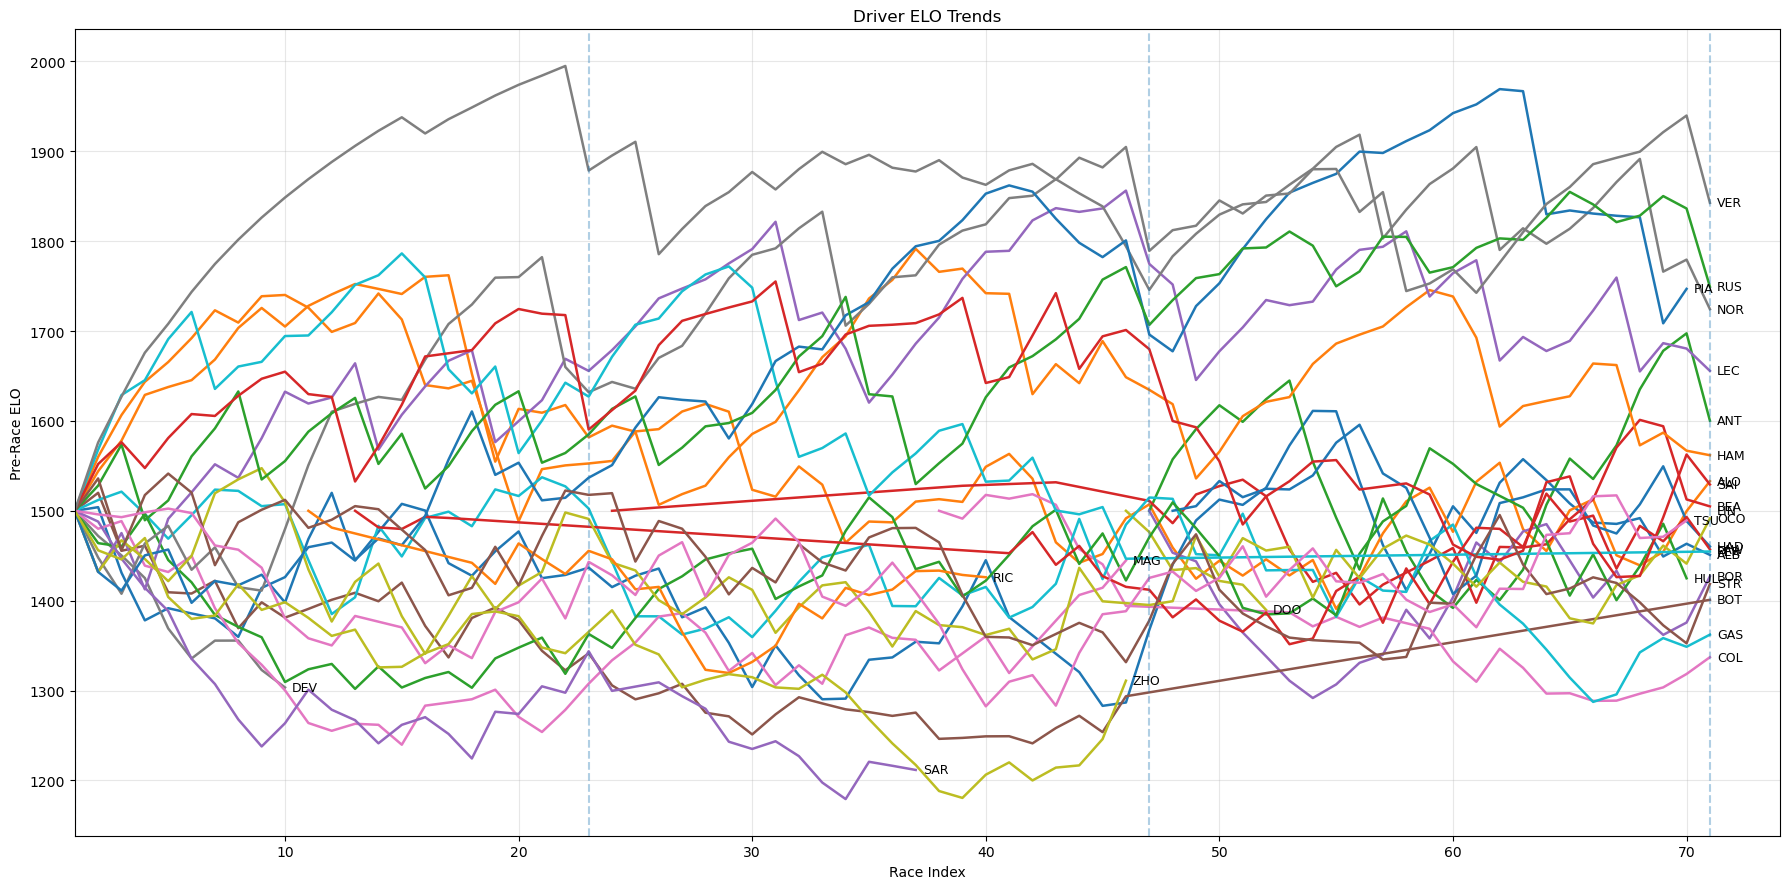

In [264]:
plt.figure(figsize=(18, 9))

# plot each driver line
for driver in sorted(elo_plot["driver"].unique()):
    sub = elo_plot[elo_plot["driver"] == driver].sort_values("race_index")
    plt.plot(sub["race_index"], sub["elo_before"], linewidth=1.8)

    # label at last point
    last_x = sub["race_index"].iloc[-1]
    last_y = sub["elo_before"].iloc[-1]

    plt.text(
        last_x + 0.3,   # push label slightly right of the line
        last_y,
        driver,
        fontsize=9,
        va="center"
    )

# season boundaries
season_starts = (
    race_order.groupby("year", as_index=False)["race_index"]
    .min()
)

for _, row in season_starts.iterrows():
    plt.axvline(row["race_index"], linestyle="--", alpha=0.35)

plt.xlabel("Race Index")
plt.ylabel("Pre-Race ELO")
plt.title(f"Driver ELO Trends")
plt.grid(True, alpha=0.3)

# extend x-axis so labels fit on the right
plt.xlim(elo_plot["race_index"].min(), elo_plot["race_index"].max() + 3)

plt.tight_layout()
plt.show()

In [265]:
elo_table.head()

,driver,driver_number,position,points,gap_to_leader,meeting_key,session_key,dnf,dns,dsq,nc,start_date,race_num,year,elo_position,elo_before,elo_delta,elo_after
0,VER,1,1.0,25.0,0,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,1.0,1500.0,76.0,1576.0
1,PER,11,2.0,18.0,11.987,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,2.0,1500.0,68.0,1568.0
2,ALO,14,3.0,15.0,38.637,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,3.0,1500.0,60.0,1560.0
3,SAI,55,4.0,12.0,48.052,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,4.0,1500.0,52.0,1552.0
4,HAM,44,5.0,10.0,50.977,1141,7953,False,False,False,False,2023-03-05 15:00:00+00:00,1,2023,5.0,1500.0,44.0,1544.0


# Saving the Elo Table

In [266]:
elo_out_path = working_directory / "data" / "semi-clean" / "elo_table.csv"
elo_table.to_csv(elo_out_path)